In [1]:
import pickle
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import matplotlib.pyplot as plt

In [2]:
# df=pd.read_csv("../dreamt_preprocessed.csv")

Removed columns with nulls: []
Data shape: (70155, 165)


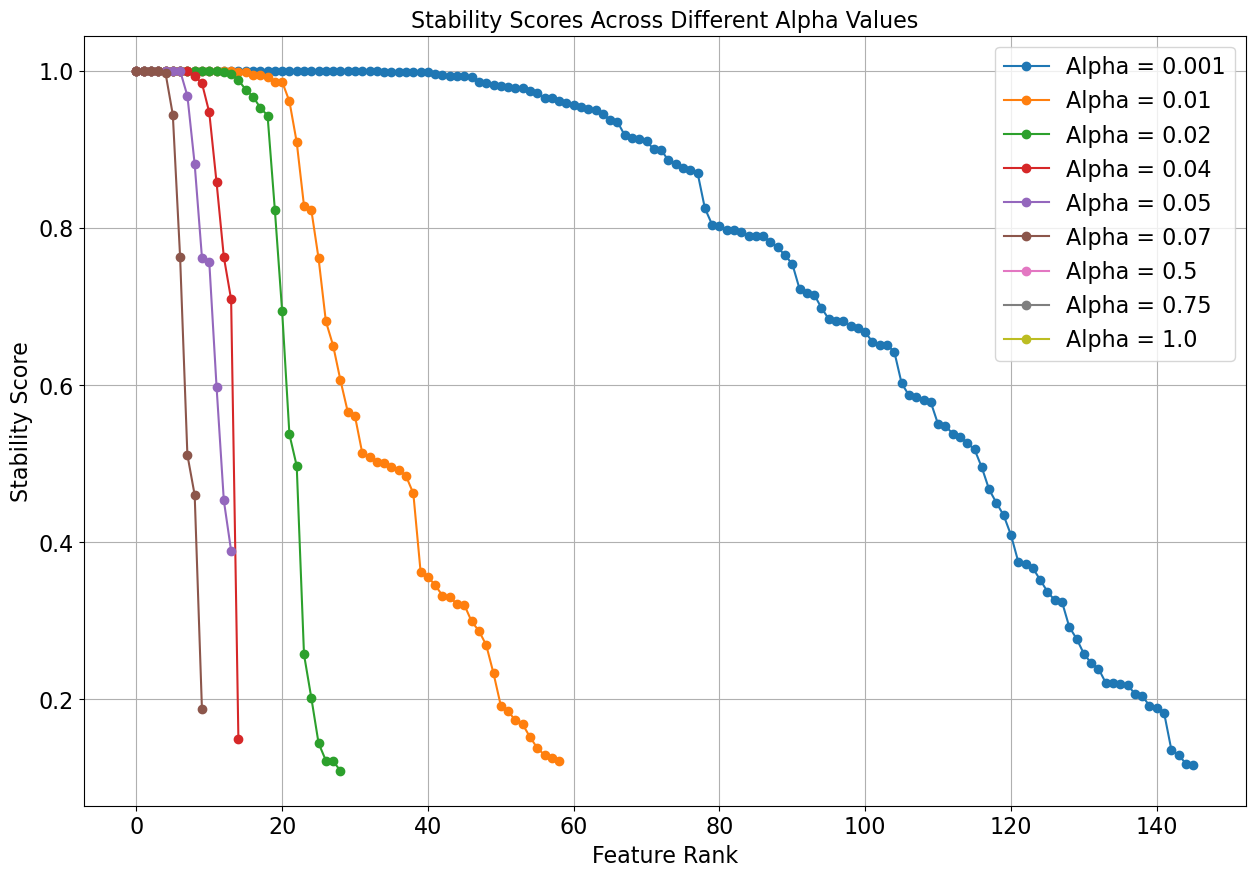

In [3]:
import pickle
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import matplotlib.pyplot as plt

# Load data
df=pd.read_csv('../dreamt_preprocessed.csv')
### Removing the skewnes and kurtosis
# Identify columns to drop if they exist
columns_to_drop = [col for col in df.columns if 'skewness' in col.lower() or 'kurtosis' in col.lower()]
# Drop only those columns that actually exist
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
df = df[~df['subject'].isin(['S062', 'S097'])]

### PSG filtering
wanted_keywords = ['BVP', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR', 'IBI']
pattern = '|'.join(wanted_keywords)
 
# Select columns that do NOT match the regex pattern
df_psg = df.loc[:, ~df.columns.str.contains(pattern, case=False, regex=True)]
df_psg
# Drop columns with any null (NaN) values
df_psg_cleaned = df_psg.dropna(axis=1, how='any')
psg_removed_cols = df_psg.columns[df_psg.isnull().any()].tolist()
print("Removed columns with nulls:", psg_removed_cols)
df_psg_cleaned
## PSG filtering stop
df_psg_cleaned = df_psg_cleaned[df_psg_cleaned['label'].isin([0,1,2])]
print(f"Data shape: {df_psg_cleaned .shape}")

# df

### Can be tested by using a few subject "#[:10]" need to remove :10 means 10 subject
sample=df_psg_cleaned.subject.unique()#[:10]
# # Sample the data (if needed)
df_sample = df_psg_cleaned[df_psg_cleaned.subject.isin(sample)]
# print(df_sample.shape)
# Split features and labels
X = df_sample.drop(columns=['subject','epoch','label'])
y = df_sample['label']

# # Split features and labels
# X = df.drop(columns=['subject','epoch','label','map_label'])
# y = df['map_label']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Number of bootstrap samples
n_bootstrap = 1000
n_features = X.shape[1]

# Alpha values to test
alpha_values = [0.001, 0.01,0.02,0.04, 0.05,0.07, 0.5, 0.75,1.0]
results = {}

# Perform Lasso stability selection for each alpha value
for alpha in alpha_values:
    feature_counts = np.zeros(n_features)
    
    for _ in range(n_bootstrap):
        X_resampled, y_resampled = resample(X_scaled, y, n_samples=int(0.75 * len(y)), random_state=None)
        
        # Train a Lasso model
        lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
        lasso.fit(X_resampled, y_resampled)
        
        # Record non-zero coefficient features
        feature_counts += (lasso.coef_ != 0).astype(int)
    
    # Calculate stability scores
    stability_scores = feature_counts / n_bootstrap
    
    # Store results in a DataFrame
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Stability_Score': stability_scores
    }).sort_values(by='Stability_Score', ascending=False)
    
    results[alpha] = feature_importance_df

# Plot stability scores for each alpha
plt.figure(figsize=(15, 10))

for alpha, df_alpha in results.items():
    filtered_df = df_alpha[df_alpha['Stability_Score'] >= 0.1]
    plt.plot(range(len(filtered_df)), filtered_df['Stability_Score'], label=f'Alpha = {alpha}', marker='o')

plt.title('Stability Scores Across Different Alpha Values',fontsize=16)
plt.xlabel('Feature Rank',fontsize=16)
plt.ylabel('Stability Score',fontsize=16)
plt.xticks(fontsize=16)  # Make x-axis tick labels larger
plt.yticks(fontsize=16)  # Make y-axis tick labels larger
plt.legend(fontsize=16)
plt.grid(True)
plt.show()

In [4]:
df.shape

(93294, 237)

In [5]:
# sample=df.subject.unique()
len(sample)

98

In [6]:
# sample=df.subject.unique()[:1000]
# # # Sample the data (if needed)
# df_sample = df[df.subject.isin(sample)]
# df_sample 

In [7]:
df_sample.subject.nunique() 

98

### The right below part is use for writing the satability scores 

In [9]:
# Define the keys you want to keep
# keep_alphas = [0.001, 0.01, 0.02, 0.04, 0.05, 0.07, 0.75,1.0]
keep_alphas = [0.001, 0.01, 0.02, 0.04, 0.05, 0.07]
# Filter the dictionary
results_filtered = {k: v for k, v in results.items() if k in keep_alphas}
results_filtered
import pickle
with open("stability_score_alpha_psg_v1.pkl", "wb") as f:
    pickle.dump(results_filtered, f)

### Reading the Save Pickle data

In [11]:
import pickle
# with open("stability_score_alpha_fusion_v1.pkl", "rb") as f:
#     results = pickle.load(f)
# results.keys()
with open("stability_score_alpha_psg_v1.pkl", "rb") as f:
    results = pickle.load(f)
results.keys()

dict_keys([0.001, 0.01, 0.02, 0.04, 0.05, 0.07])

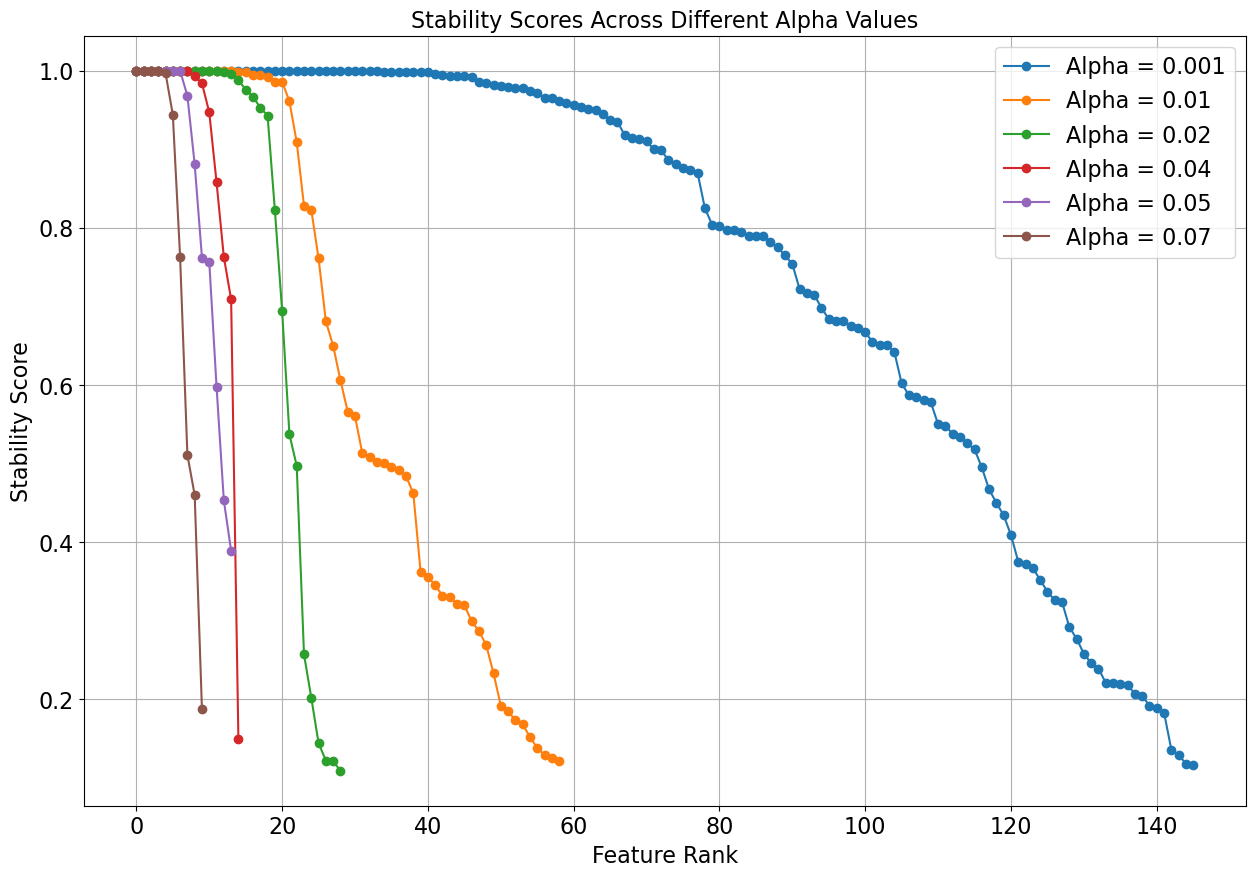

In [12]:
# Plot stability scores for each alpha
plt.figure(figsize=(15, 10))

for alpha, df_alpha in results.items():
    filtered_df = df_alpha[df_alpha['Stability_Score'] >= 0.1]
    plt.plot(range(len(filtered_df)), filtered_df['Stability_Score'], label=f'Alpha = {alpha}', marker='o')

plt.title('Stability Scores Across Different Alpha Values',fontsize=16)
plt.xlabel('Feature Rank',fontsize=16)
plt.ylabel('Stability Score',fontsize=16)
plt.xticks(fontsize=16)  # Make x-axis tick labels larger
plt.yticks(fontsize=16)  # Make y-axis tick labels larger
plt.legend(fontsize=16)
plt.grid(True)
plt.show()

In [13]:
### Check the penalized parameter (alpha) that was stored as a dictionary 

In [14]:
results.keys()

dict_keys([0.001, 0.01, 0.02, 0.04, 0.05, 0.07])

In [15]:
# feature_importance_df_07=results[0.01][results[0.01].Stability_Score>0.7]
feature_importance_df=results[0.01]
feature_importance_df

,Feature,Stability_Score
81,ECG_min,1.0
95,PTAF_p25,1.0
145,RAT_max,1.0
15,F4-M1_p50,1.0
77,CHIN_p25,1.0
...,...,...
64,E2_max,0.0
62,E1_p95,0.0
58,E1_p5,0.0
57,E1_std,0.0


### If we want to see features with a spefic threshold

In [17]:
results[0.02][results[0.02].Stability_Score>0.6]

,Feature,Stability_Score
81,ECG_min,1.000
145,RAT_max,1.000
91,PTAF_max,1.000
97,PTAF_p75,1.000
87,ECG_p50,1.000
100,FLOW_max,1.000
104,FLOW_p25,1.000
77,CHIN_p25,1.000
117,ABDOMEN_min,1.000
33,FP1-O2_p50,1.000


In [18]:
len(results[0.02][results[0.02].Stability_Score>0.2])

25

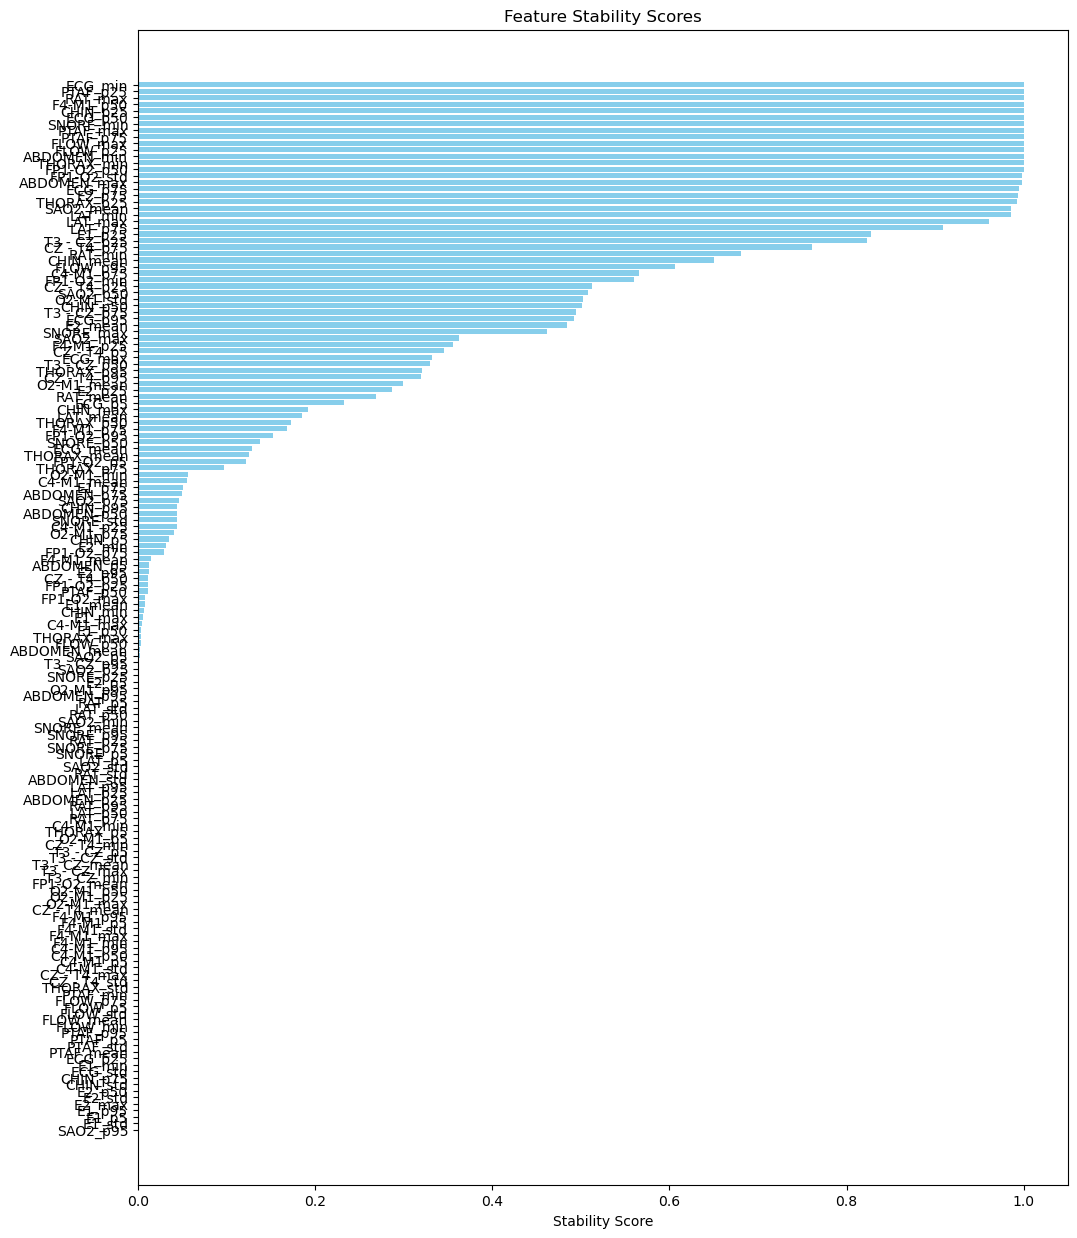

In [19]:
# Plotting the features vs. stability scores
feature_importance_df=results[0.01]
plt.figure(figsize=(12, 15))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
plt.xlabel('Stability Score')
plt.title('Feature Stability Scores')
plt.gca().invert_yaxis()
plt.show()

In [20]:
# # Plotting the features vs. stability scores
# feature_importance_df=results[0.02]
# plt.figure(figsize=(12, 15))
# plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
# plt.xlabel('Stability Score')
# plt.title('Feature Stability Scores')
# plt.gca().invert_yaxis()
# plt.show()

In [21]:
# # Plotting the features vs. stability scores
# feature_importance_df=results[0.05]
# plt.figure(figsize=(12, 15))
# plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
# plt.xlabel('Stability Score')
# plt.title('Feature Stability Scores')
# plt.gca().invert_yaxis()
# plt.show()

In [22]:
feature_importance_df_07=results[0.02][results[0.02].Stability_Score>=0.7]['Feature'].values
feature_importance_df_07
sel_col=np.append(feature_importance_df_07,'label')
sel_col

array(['ECG_min', 'RAT_max', 'PTAF_max', 'PTAF_p75', 'ECG_p50',
       'FLOW_max', 'FLOW_p25', 'CHIN_p25', 'ABDOMEN_min', 'FP1-O2_p50',
       'FP1-O2_std', 'PTAF_p25', 'F4-M1_p50', 'ABDOMEN_max', 'SNORE_min',
       'LAT_min', 'E2_p75', 'LAT_max', 'SAO2_mean', 'THORAX_min', 'label'],
      dtype=object)

## selecting the features that  have stability scores more that 0.7

In [24]:
df_sample.columns

Index(['subject', 'epoch', 'label', 'C4-M1_min', 'C4-M1_max', 'C4-M1_mean',
       'C4-M1_std', 'C4-M1_p5', 'C4-M1_p25', 'C4-M1_p50',
       ...
       'RAT_p95', 'SAO2_min', 'SAO2_max', 'SAO2_mean', 'SAO2_std', 'SAO2_p5',
       'SAO2_p25', 'SAO2_p50', 'SAO2_p75', 'SAO2_p95'],
      dtype='object', length=165)

In [25]:
df1=df_sample[sel_col]
df1

,ECG_min,RAT_max,PTAF_max,PTAF_p75,ECG_p50,FLOW_max,FLOW_p25,CHIN_p25,ABDOMEN_min,FP1-O2_p50,...,PTAF_p25,F4-M1_p50,ABDOMEN_max,SNORE_min,LAT_min,E2_p75,LAT_max,SAO2_mean,THORAX_min,label
305,-0.000207,0.000047,0.003166,-0.000341,-0.000007,0.000063,-0.000013,-0.000004,-0.000471,4.394598e-07,...,-0.001435,5.371176e-07,0.000736,-0.000060,-0.000070,0.000006,0.000067,0.969924,-0.001793,0.0
306,-0.000223,0.000012,0.003147,-0.000843,-0.000005,0.000072,-0.000028,-0.000004,-0.000599,-5.371176e-07,...,-0.001557,1.464866e-07,0.001070,-0.000007,-0.000010,0.000005,0.000010,0.966985,-0.001988,0.0
307,-0.000250,0.000019,0.003180,-0.000877,-0.000005,0.000066,-0.000018,-0.000004,-0.000575,-5.371176e-07,...,-0.001517,-4.882887e-08,0.000878,-0.000021,-0.000011,0.000006,0.000010,0.969924,-0.001837,0.0
308,-0.000198,0.000016,0.002983,-0.000649,-0.000006,0.000057,-0.000019,-0.000004,-0.000454,-3.906310e-07,...,-0.001292,-4.882887e-08,0.000935,-0.000007,-0.000024,0.000005,0.000029,0.969924,-0.002062,0.0
309,-0.001434,0.000133,0.003143,-0.000585,-0.000005,0.000091,-0.000028,-0.000004,-0.000692,-1.464866e-07,...,-0.001336,5.371176e-07,0.000929,-0.000036,-0.000073,0.000006,0.000045,0.969924,-0.001950,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95142,-0.000938,0.000009,0.001244,0.000026,0.000033,0.000433,-0.000120,-0.000002,-0.000346,3.418021e-07,...,-0.000089,4.882887e-08,0.000345,-0.000057,-0.000031,0.000004,0.000060,0.914902,-0.001019,1.0
95143,-0.000972,0.000053,0.002186,0.000049,0.000033,0.000614,-0.000134,-0.000002,-0.000639,4.882887e-08,...,-0.000196,-1.464866e-07,0.000528,-0.000042,-0.000049,0.000005,0.000116,0.926600,-0.000925,1.0
95144,-0.000965,0.000009,0.000935,0.000039,0.000032,0.000320,-0.000165,-0.000002,-0.000259,-4.882887e-08,...,-0.000120,2.441444e-07,0.000334,-0.000028,-0.000024,0.000004,0.000020,0.929748,-0.000432,1.0
95145,-0.000958,0.000009,0.001406,0.000021,0.000033,0.000299,-0.000151,-0.000002,-0.000310,1.464866e-07,...,-0.000097,2.441444e-07,0.000230,-0.000030,-0.000017,0.000004,0.000009,0.917330,-0.000757,1.0
